In [6]:
# Import PyRadtran components
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('../config/albedo.yaml')
import logging
# change to "DEBUG" if you want to see more output
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

N_timesteps = 24

# stationary simulation at constant altitude, latitude, and longitude but with varying time
ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2025-04-04T12:00:00', periods=N_timesteps, freq='s'),
        'latitude' : ('time', [51.3406321] * N_timesteps),
        'longitude' : ('time', [12.3747329] * N_timesteps),
        #'altitude' : ('time', [10] * N_timesteps),
    },
    data_vars={
        'albedo' : ('time', np.linspace(0.1, 0.9, N_timesteps)),
    }
)
# Run a spectral simulation for a single point
ds_sim = ds.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
    albedo_var='albedo',
)

print("\nSimulation complete!")

2025-07-21 15:06:47,662 - pyradtran.config - INFO - Loading configuration from: ../config/albedo.yaml
2025-07-21 15:06:47,673 - pyradtran.config - INFO - Configuration loaded successfully.



Simulation complete!


Text(0.5, 1.0, 'Upwelling Inegrated Irradiance (400nm - 700nm) vs Albedo')

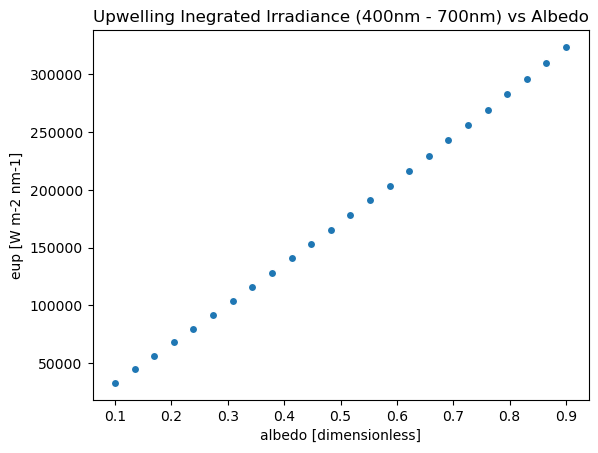

In [16]:
ds_sim.plot.scatter(
    x = 'albedo',
    y = 'eup'
)
plt.title('Upwelling Inegrated Irradiance (400nm - 700nm) vs Albedo')